In [3]:
using Plots
using Printf

In [4]:
# create some input / output data

x = [0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.60, 1.65, 1.90]
y = [0.67, 0.85, 1.05, 1.0, 1.40, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6]

println(x)
println(y)

[0.03, 0.19, 0.34, 0.46, 0.78, 0.81, 1.08, 1.18, 1.39, 1.6, 1.65, 1.9]
[0.67, 0.85, 1.05, 1.0, 1.4, 1.5, 1.3, 1.54, 1.55, 1.68, 1.73, 1.6]


In [5]:
# Define 1D linear regression model 
function f(x, ϕ₀, ϕ₁)
    y = ϕ₀ .+ ϕ₁ .* x 
    return y
end

f (generic function with 1 method)

In [6]:
function plot_model(x, y, ϕ₀, ϕ₁)
    scatter(x, y;
        xlims = (0, 2.0),
        ylims = (0, 2.0),
        xlabel = "Input, x",
        ylabel = "Output, y",
        legend = false,
        title = "1D Linear Regression Model")
    
    #Draw line 
    x_line = 0:0.01:2.0
    y_line = f(x_line, ϕ₀, ϕ₁)
    plot!(x_line, y_line, color = :red, lw = 2)
end

plot_model (generic function with 1 method)

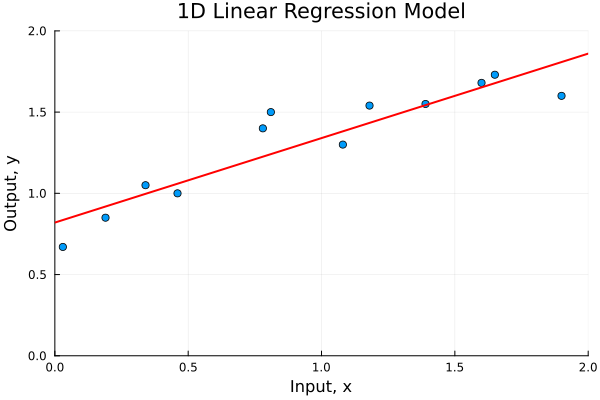

In [7]:
plot_model(x, y, 0.82, 0.52)

In [8]:
# Function to calculate the loss (mean squared error) for given parameters
function compute_loss(x, y, ϕ₀, ϕ₁)
    loss = sum((f(x, ϕ₀, ϕ₁) .- y).^2)
    return loss
end

compute_loss (generic function with 1 method)

In [9]:
loss = compute_loss(x, y, 0.4, 0.2)
@printf("Your Loss = %3.2f, Ground truth =7.07\n", loss)

Your Loss = 7.07, Ground truth =7.07


In [10]:
# Set the intercept and slope as in figure 2.2c
ϕ₀ = 1.60; ϕ₁ = -0.8
# Plot the data and the model 
plot_model(x, y, ϕ₀, ϕ₁)
loss = compute_loss(x, y, ϕ₀, ϕ₁)
@printf("Your Loss = %3.2f, Ground truth = 10.28\n", loss)

Your Loss = 10.28, Ground truth = 10.28


Your Loss = 1.98


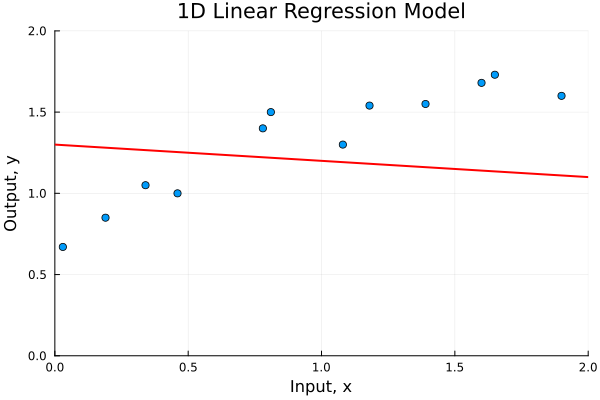

In [41]:

# TODO -- Change the parameters manually to fit the model
# First fix phi1 and try changing phi0 until you can't make the loss go down any more
# Then fix phi0 and try changing phi1 until you can't make the loss go down any more
# Repeat this process until you find a set of parameters that fit the model as in figure 2.2d
# You can either do this by hand, or if you want to get fancy, write code to descent automatically in this way
# Start at these values:

ϕ₀ = 1.3; ϕ₁ = -0.1


println("Your Loss = $(round(compute_loss(x, y, ϕ₀, ϕ₁), digits=2))")
plot_model(x, y, ϕ₀, ϕ₁)

## Visualizing the Loss Function

In [ ]:
# Make grid of possible ϕ₀ and ϕ₁ values
ϕ₀_range = 0.0:0.02:2.0
ϕ₁_range = -1.0:0.02:1.0

# Make a 2D array of loss values for each combination of ϕ₀ and ϕ₁
ϕ₀_mesh = [p₀ for p₁ in ϕ₁_range, p₀ in ϕ₀_range]
ϕ₁_mesh = [p₁ for p₁ in ϕ₁_range, p₀ in ϕ₀_range]

loss_mesh = [compute_loss(x, y, p₀, p₁) for p₁ in ϕ₁_range, p₀ in ϕ₀_range]




101×101 Matrix{Float64}:
 71.863    70.7766   69.6998   68.6326   …  11.0246   10.879    10.743
 70.578    69.5007   68.433    67.375       10.6341   10.4976   10.3708
 69.3049   68.2368   67.1783   66.1293      10.2556   10.1283   10.0105
 68.0439   66.9849   65.9355   64.8957       9.88917   9.77095   9.66234
 66.7949   65.745    64.7048   63.6741       9.53471   9.42562   9.32613
 65.5579   64.5172   63.486    62.4645   …   9.19226   9.0923    9.00194
 64.333    63.3013   62.2793   61.2669       8.86182   8.77099   8.68976
 63.12     62.0975   61.0846   60.0813       8.54339   8.46169   8.38959
 61.919    60.9056   59.9019   58.9077       8.23697   8.1644    8.10142
 60.7301   59.7258   58.7312   57.7461       7.94256   7.87912   7.82527
 59.5531   58.558    57.5725   56.5966   …   7.66016   7.60584   7.56112
 58.3882   57.4022   56.4258   55.459        7.38977   7.34458   7.30899
 57.2353   56.2584   55.2911   54.3335       7.13139   7.09533   7.06886
  ⋮                           

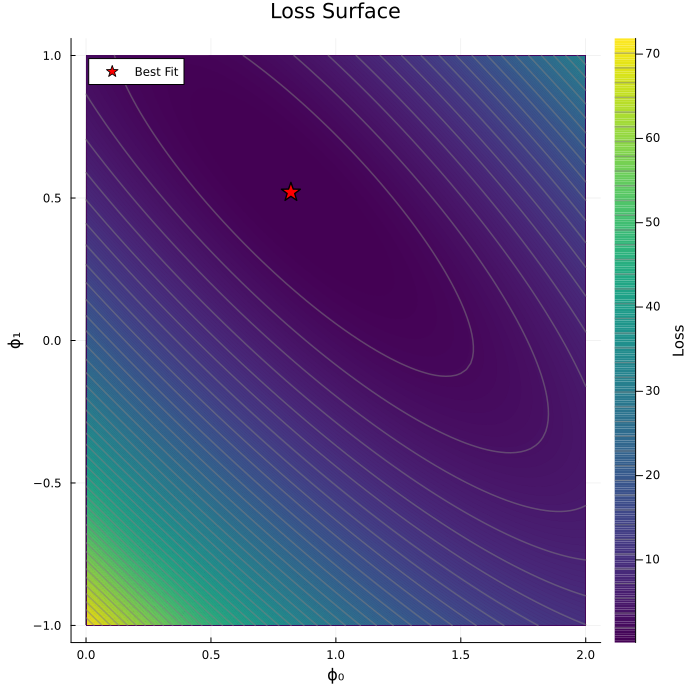

In [46]:
# Plot the loss surface as heat map 
contourf(ϕ₀_range, ϕ₁_range, loss_mesh; 
    levels = 256,
    linewidth = 0,
    color = :viridis,
    size = (700, 700),
    xlabel = "ϕ₀",
    ylabel = "ϕ₁",
    title = "Loss Surface",
    colorbar_title = "Loss")

# Overlay contour maps 
contour!(ϕ₀_range, ϕ₁_range, loss_mesh; 
    levels = 40,
    linewidth = 1.5,
    color = :gray,
    alpha = 0.5)


# Mark your best-fit 
ϕ₀ = 0.82; ϕ₁ = 0.52

scatter!([ϕ₀], [ϕ₁]; color = :red, marker = :star5, markersize = 10, label = "Best Fit")